In [1]:
#Loading datset
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.head())
print(y.head())

print("Shape:", X.shape)
print("Classes:", data.target_names)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [2]:
#Checking for missing values
print(X.isnull().sum().sum())

0


In [3]:
print(y.value_counts())

target
1    357
0    212
Name: count, dtype: int64


In [4]:
#Feature scaling for Linear Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
#Train test split using 80:20 split for decision tree
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size =  0.2,
    random_state = 50,
    stratify = y
)

In [8]:
#Train test split using 80:20 split for linear regression using scaled data
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

In [10]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state = 50
)

In [11]:
#Importing model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=50)

In [12]:
dt_predictions = dt_model.predict(X_test)

In [13]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [14]:
lr_predictions = lr_model.predict(X_test_scaled)

In [17]:
#producing threshold values since Linear regression produce values like 0.12 which aren't directly classes. So if prediction is < 0.5 it is considered as 0 or else 1.
lr_predictions_output = (lr_predictions >= 0.5).astype(int)

In [ ]:
#Testing the model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
#Decision tree
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)

In [ ]:
#LinearRegression 
lr_acccuracy = accuracy_score(y_test, lr_predictions_output)
lr_precision = precision_score(y_test, lr_predictions_output)
lr_recall = recall_score(y_test, lr_predictions_output)
lr_f1 = f1_score(y_test, lr_predictions_output)

In [21]:
print("Decision Tree")
print("Accuracy", dt_accuracy)
print("Precision", dt_precision)
print("Recall", dt_recall)
print("F1 Score", dt_f1)

Decision Tree
Accuracy 0.956140350877193
Precision 0.9466666666666667
Recall 0.9861111111111112
F1 Score 0.9659863945578231


In [23]:
print("Linear Regression")
print("Accuracy :", lr_acccuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Linear Regression
Accuracy : 0.9385964912280702
Precision: 0.9113924050632911
Recall   : 1.0
F1 Score : 0.9536423841059603


In [ ]:
#Comparision Table
results = pd.DataFrame({
    "Model": ["Decision Tree", "Linear Regression"],
    "Accuracy": [dt_accuracy, lr_acccuracy],
    "Precision": [dt_precision, lr_precision],
    "Recall": [dt_recall, lr_recall],
    "F1 Score": [dt_f1, lr_f1]
})

print(results)

               Model  Accuracy  Precision    Recall  F1 Score
0      Decision Tree  0.956140   0.946667  0.986111  0.965986
1  Linear Regression  0.938596   0.911392  1.000000  0.953642


In [25]:
dt_train_predictions = dt_model.predict(X_train)

print("Decision Tree Training Accuracy:",
      accuracy_score(y_train, dt_train_predictions))

print("Decision Tree Testing Accuracy:",
      accuracy_score(y_test, dt_predictions))

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.956140350877193


In [27]:
lr_train_output = lr_model.predict(X_train_scaled)
lr_train_predictions = (lr_train_output >= 0.5).astype(int)

print("Linear Regression Training Accuracy:",
      accuracy_score(y_train, lr_train_predictions))

print("Linear Regression Testing Accuracy:",
      accuracy_score(y_test, lr_predictions_output))

Linear Regression Training Accuracy: 0.9604395604395605
Linear Regression Testing Accuracy: 0.9385964912280702


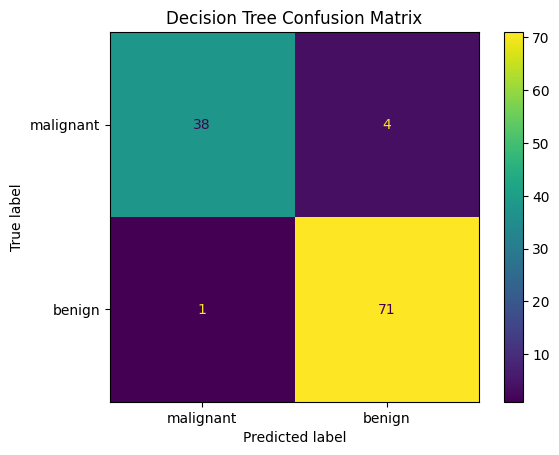

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, dt_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

display.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

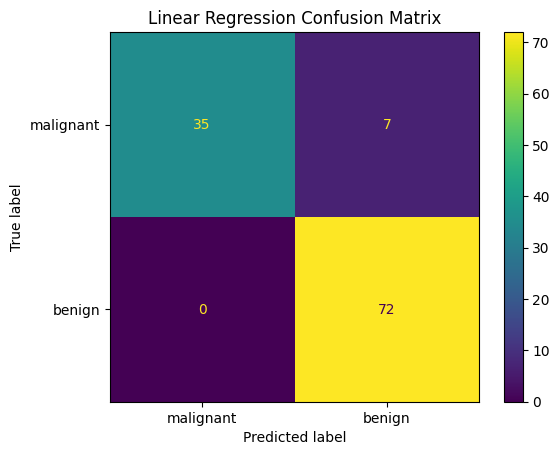

In [30]:
cm = confusion_matrix(y_test, lr_predictions_output)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

display.plot()
plt.title("Linear Regression Confusion Matrix")
plt.show()